# 0. Libraries

## 0.1 Libraries Import

In [3]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from scipy.stats import randint
import statsmodels.api as sm

import markdown

import warnings
warnings.filterwarnings('ignore')


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge

from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier 
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline
impipeline = Pipeline

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import category_encoders as ce

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler

from collections import defaultdict

from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, RocCurveDisplay, roc_auc_score, mean_squared_error
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, fbeta_score
from sklearn.metrics import make_scorer
f2_scorer = make_scorer(fbeta_score, beta=2)
f05_scorer = make_scorer(fbeta_score, beta=0.5)

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate

import shap

from scipy.stats import chi2_contingency, pointbiserialr

import dice_ml
from dice_ml import Data, Model, Dice

## 0.2. Load Data

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df_bank = pd.read_csv('bank-additional-full.csv', sep=';')

# 1. Business Metrics Set-up

## 1.0. Dataframe

In [7]:
df_bank_sbx =  df_bank.copy()

In [8]:
df_bank_sbx.y.isna().sum()

np.int64(0)

## 1.1. Marketing Cost Components

This is a prediction cost for calling 1 customer to offer the deposit bank program. We calculate that to succeed the calls, it is expected €2.96 for 1 customer call which already includes estimation of number of calls per customer with maximum duration for each in minutes.

In [9]:
# Call Count                                                             (Number of Calls)
monthly_total_calls = df_bank_sbx.groupby(['month'])['campaign'].sum()
avg_monthly_calls = monthly_total_calls.mean()

# Telemarketing Softwar Subscription (per agent)                         (Cost Call Per Telemarketer (Essential))
monthly_subscription = 25

# Telemarketer Agent                                                     (Estimate Telemarketer Wages (Euro))
monthly_agent_wage = 805

# Work Duration                                                          (Effective Works (Days) | Effective Works Hours/ Day | Maximum Minutes in a Month)
monthly_work_days = 20
daily_work_hour = 8
monthly_work_minutes = monthly_work_days * daily_work_hour * 60

# Call Duration                                                          (Standard Maximum Call per Person in minute)
q3_duration =  np.quantile(df_bank_sbx['duration'], 0.75)/60
q1_duration =  np.quantile(df_bank_sbx['duration'], 0.25)/60
iqr_duration = q3_duration - q1_duration
proposed_call_dur_min = q3_duration + iqr_duration
# proposed_call_dur_min = 7

# Expected Max Monthly Call                                              (Expected Maximum call )
avg_monthly_max_callminute = monthly_work_minutes / proposed_call_dur_min

# Minutes Spent Monthly                                                  Number of Minutes in a Month
monthly_minutes_spent = avg_monthly_calls * proposed_call_dur_min

# Agent needed                                                           Number of Telemarketer Needed
avg_agent_needed = math.ceil( avg_monthly_calls / avg_monthly_max_callminute )

# Avg Monthly Telemarketer Cost                                          Estimate Cost for Telemarketing 
avg_monthly_cost_telemarkting = avg_agent_needed * ( monthly_subscription + monthly_agent_wage )

# Cost in minute                                                         Convert cost in Minute
avg_minute_cost_telemarkting = avg_monthly_max_callminute / avg_monthly_cost_telemarkting 

# Cost per call                                                          Avg cost per minute
cost_per_call = avg_minute_cost_telemarkting * proposed_call_dur_min

# Average calls per person
avg_call_per_person = df_bank_sbx['campaign'].mean()

# Total Cost Component : Average final total cost per call
final_avg_cost_per_customer = cost_per_call * avg_call_per_person

In [10]:
final_avg_cost_per_customer

np.float64(2.969745545257655)

## 1.2. Deposit Cost & Benefit Components

Variable explanation : 

- **Deposit Amount Revenue (_deposit_amount_)**

    This is the amount of the customer's deposit. In this case, each customer who confirms yes to subscribe the deposit is expected to subscribe to the minimum deposit amount, that is 500€. Total revenue is the deposit subscribed by the customer crossed with the total customer applied for the deposit program. 

- **Interest Income (_interest_income_)**
    Interest income represents the interest gained by the bank for every asset (represented by the deposit). Based on the Net Interest Margin (NIM) formula explained below, we will be utilizing the ratio between income and interest
 
        NIM = (Interest Income - Interest Expense) / Assets x 100%

    As the ratio between interest expense is known (41.58%) we now understand that interest rate used will be 4.78%

        Interest Income = 2.79% (NIM) / (1 - 41.58% (expense to income ratio))

- **Interest Expense (_interest_expense_)**
    Interest expense is an outflow measure of interest paid on deposits, borrowings, and other interest-bearing liabilities. This component reflects the cost of funds used for operations within the context of assets and its interests. This is calculated with interest expense to income ratio:
 
        Interest Expense = Interest Income * 41.58% (expense to income ratio)

- **Deposit Income Tax (_deposit_income_tax_)**
    This term for the tax that the bank should pay from the gain of interest(2). This number is gained by crossing the total of Interest Deposit with 21%. 
 
        Deposit Income Tax = Interest Net Income x Tax (21%)

- **Total Cost (_all_costs_)**
    This variable is used to calculate all costs of users contacted and deposited 
 
        Total Cost = Interest Expense + Deposit Tax + Cost of Marketing



In [11]:
#Deposit Amount
deposit_amount = 500

#NIM (Net Interest margin, %) = (Interest Income - Interest Expense) / Average Interest-Earning Assets

#NIM Explains the ratio of net interest income made from asset compred to the total asset
#Interest Income: This is the revenue a bank generates from its assets that earn interest. Key examples include:
    # Loans: Interest earned from mortgages, personal loans, and other lending activities.
    # Securities: Income from investments in government or corporate bonds and other fixed-income instruments.
    # Other Interest-Bearing Assets: Any other assets that generate interest income.
# Interest Expense: This represents the costs a bank incurs for funding itself. It includes:
    # Interest-Bearing Deposits: Interest paid to customers on their savings and checking accounts.
    # Non-Deposit Liabilities: Interest paid on wholesale funding, such as borrowed funds from other banks or issued bonds.
deposit_nim = 0.0279

# Interest Expense to Interest Income Ratio
interest_expense_to_income_ratio = 0.4158

# Interest Rate
interest_rate = deposit_nim / ( 1 - interest_expense_to_income_ratio )

# Total Income Component : Interest Income
interest_income = deposit_amount * interest_rate
interest_income_y2 = (deposit_amount + interest_income) * interest_rate

# Total Cost Component : Interest Expense
interest_expense = interest_income * interest_expense_to_income_ratio

# Total Cost Component : Interest infcome tax
tax_rate = 0.21
deposit_income_tax = interest_income * tax_rate

# Total Cost Component : All components
all_costs = final_avg_cost_per_customer + interest_expense + deposit_income_tax

In [12]:
net_profit = interest_income - deposit_income_tax - interest_expense - final_avg_cost_per_customer
net_profit

np.float64(5.965704643034025)

## 1.3. Portugal Bank Marketing Campaign Performance

In [13]:
#Income
originaldata_income = round( df_bank[df_bank['y']=='yes']['y'].count() * interest_income )

#Costs
originaldata_costs = round( df_bank['y'].count() * all_costs )

#Net Profit
originaldata_net_profit = originaldata_income - originaldata_costs

#Conversion Rate
originaldata_conv_rate = (df_bank[df_bank['y']=='yes']['y'].count() / (df_bank['y'].count())).round(2)

#ROI
originaldata_roi = round( (originaldata_income - originaldata_costs) / originaldata_costs , 2)

In [14]:
campaign_summary_data = [
                        ['Revenue', originaldata_income],
                        ['Cost', originaldata_costs],
                        ['ROI', originaldata_roi],
                        ['Conversion Rate', originaldata_conv_rate],
                        ]
campaign_summary = pd.DataFrame(campaign_summary_data, columns=['Metric', 'Value'])

campaign_summary

,Metric,Value
0,Revenue,110798.00
1,Cost,737805.00
2,ROI,-0.85
3,Conversion Rate,0.11


The Portugal Bank's marketing campaign shown a performance that could be improved with -85% ROI, and 11% conversion rate.
The aim of the machine learning model that we are going to build is to increase these performance of these metrics.

## 1.4. Functions to calculate Business Metrics

Below we created a function to calculate business metrics after modelling is done.
This function calculates the machine learning models' performance within these metrics:
- Revenue
- Cost
- ROI
- Conversion Rate
- Lost Opportunity
- Confusion Matrix

In [74]:
def business_metrics_func(y_true, y_pred, model_nme):
    # Confusion Matrix Components
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))
    TN = sum((y_true == 0) & (y_pred == 0))

    func_income = TP * interest_income
    func_income_y2 = TP * interest_income_y2
    
    func_cost = ( TP * all_costs ) + ( FP * final_avg_cost_per_customer )
    func_cost_y2 = func_cost + ( func_income_y2 * tax_rate )

    func_roi = (func_income - func_cost) / func_cost
    func_roi_y2 = (func_income_y2 - func_cost_y2) / func_cost

    func_conv_rate = TP / (TP + FP)
    
    func_lost_oppt = ( FN * interest_income ) - ( FN * all_costs )
    func_lost_oppt_y2 = func_lost_oppt + ( FN * interest_income_y2 ) - ( FN * deposit_amount * interest_rate * tax_rate )

    model_summary = [
                        ['Model', model_nme],
                        ['Revenue', round(func_income)],
                        # ['Revenue', round(func_income_y2)],
                        ['Cost', round(func_cost)],
                        # ['Cost', round(func_cost_y2)],
                        ['ROI', round(func_roi, 2)],
                        # ['ROI', round(func_roi_y2, 2)],
                        ['Conversion Rate', round(func_conv_rate, 2)],
                        ['Lost Opportunity', round(func_lost_oppt)],
                        # ['Lost Opportunity', round(func_lost_oppt_y2)],

                        ['True Positive', TP],
                        ['False Positive', FP],
                        ['True Negative', TN],
                        ['False Negative', FN],
                        
                        ]
    model_summary_df = pd.DataFrame(model_summary, columns=['Metric', 'Value'])
    return model_summary_df

# 2. Preprocessing

In [16]:
df = df_bank.copy()

## 2.1. Data Cleaning

In the code section below, we converted the value within the target variable `y` as: 

* 0 for `no` values
* 1 for `yes` values

In [17]:
df.y = df.y.map({'no':0, 'yes':1}).astype('int64')

In the code section below, we also converted the value of various features/columns:

* Mapping numerical values to `education` variable starting from 1 for the lowest form of education to the highest
* Mapping numerical values to `month` variable representing month of the year
* Mapping numerical values to `day_of_week` variable representing day of the week

In [18]:
df['education'] = df['education'].map(
            {'unknown': 1, 
            'illiterate': 1, 
            'basic.4y': 2, 
            'basic.6y': 3, 
            'basic.9y': 4, 
            'high.school': 5, 
            'professional.course': 6, 
            'university.degree': 7})

df['month'] = df['month'].map(
            {'jan': 1,
            'feb': 2,
            'mar': 3,
            'apr': 4,
            'may': 5,
            'jun': 6,
            'jul': 7,
            'aug': 8,
            'sep': 9,
            'oct': 10,
            'nov': 11,
            'dec': 12})

df['day_of_week'] = df['day_of_week'].map(
            {'mon': 1,
            'tue': 2,
            'wed': 3,
            'thu': 4,
            'fri': 5,
            'sat': 6,
            'sun': 7})


We also converted a new column from `poutcome` column to simplify the column, defined as whether the customer has previously been contacted or not:

* Mapping values such as `success` and `failure` indicating the customer having been previously contacted to `1`
* Mapping values such as `nonexistent` indicating that the customer never previously contacted before to `0`

In [19]:
df['past_contacted'] = df['poutcome'].map({
    'nonexistent': 0, 
    'failure': 1, 
    'success': 1
})


## 2.2. Feature Engineering

In [20]:
df_modified = df.copy()

### 2.2.1. RobustScaler Preparation - Outlier

In [21]:
def calculate_outlier_percentage(df):

    outlier_percentages = {}
    for column in df.select_dtypes(include=np.number).columns:  
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        # Get percentage of outliers
        total_rows = len(df)
        num_outliers = len(outliers)
        
        if total_rows > 0:
            percentage = (num_outliers / total_rows) * 100
        else:
            percentage = 0  # Handle empty case

        outlier_percentages[column] = percentage
    
    return pd.Series(outlier_percentages)


# Calculate percentage
outliers = calculate_outlier_percentage(df_modified).reset_index()
outlier_columns = outliers[ (outliers[0]>0) & (outliers['index']!='y') & (outliers['index']!='duration')]['index']
outlier_list = outlier_columns.tolist()
outlier_list

['age', 'campaign', 'pdays', 'previous', 'cons.conf.idx', 'past_contacted']

In the step above, we tried to find features with outliers and normalize the value with Robust Scaler in the pipeline.

 Each feature value is transformed by subtracting the median and then dividing by the IQR $$X_{\text{scaled}}=\frac{X-\text{median}(X)}{IQR(X)}$$
    <br>

`age`, `campaign`, `pdays`, `previous`, `cons.conf.idx`, `past_contacted` are found to be features with outliers and will be passed into Robust Scaler step in the pipeline.

### 2.2.2. Preprocessing Pipeline

In the preprocessing pipeline, we used OneHotEncoder for categorical features such as `marital`, `contact`, `default`, `housing`, `loan`, `poutcome` for their unique value of 3 unique values. Binary Encoder used for `job` as it has more unique values.

In [22]:
# Pipelining
preprocessor = ColumnTransformer(
    [
        ('onehot_encoding', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['marital', 'contact', 'default', 'housing', 'loan', 'poutcome']),
        ('binary_encoding', ce.BinaryEncoder(), ['job']),
        ('scaler', RobustScaler(), outlier_list),
        ('passthrough_col', 'passthrough', list(set(['age', 'campaign', 'cons.conf.idx', 'past_contacted', 
                                            'education', 'month', 'day_of_week', 'emp.var.rate', 'cons.price.idx',
                                            'euribor3m', 'nr.employed']
                                            ).difference(outlier_list))
            )
    ],
    verbose_feature_names_out=False,
    remainder='passthrough',
    ).set_output(transform="pandas")

preprocessor

,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [23]:
pipe_preproc = Pipeline(steps=[
    ('feature engineering', preprocessor)
    ])
pipe_preproc

,steps,"[('feature engineering', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 2.2.3. Train-Test Split

In [24]:
# Creating a new dataframe for further operation
df_split = df_modified.copy()

In [25]:
# Train-test split

y = df_split['y']
X = df_split.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=2042)

# 3. Model Experimentation

### 3.1. List of Models

In [26]:
weight_estimate = sum(y==0) / sum(y==1) # Estimate for xgboost weight
weight_estimate

rf = RandomForestClassifier(class_weight='balanced', random_state=2042)
xg = XGBClassifier(scale_pos_weight=weight_estimate, random_state=2042, enable_categorical=True)
lr = LogisticRegression(class_weight='balanced', random_state=2042)
lg = LGBMClassifier(scale_pos_weight=weight_estimate, random_state=2042)

#List of models
models=[
    ('Logistic Regression', lr),
    ('Random Forest Classifier', rf),
    ('XGB Classifier', xg),
    ('LGBM Classifier', lg)
]

In [27]:
pipe_rf = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', rf)
    ])

pipe_xg = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', xg)
    ])

pipe_lr = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', lr)
    ])

pipe_lg = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', lg)
    ])

### 3.2. Models Score

In [28]:
results_sm = defaultdict(list)

for mname, m in models:
    
    pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', m)
    ])

    # Cross-validate F2 Score for each model
    f2_score_result  = cross_val_score(pipe_model, X_train, y_train, cv=6, scoring=f2_scorer)

    # Collect results
    results_sm['Model'].append( mname )
    results_sm['F2 Score Mean'].    append( f2_score_result[~np.isnan(f2_score_result )].mean() )
    results_sm['F2 Score Stdev'].   append( f2_score_result[~np.isnan(f2_score_result )].std() )

# Gather the results into dataframe
selection_results_df = pd.DataFrame(results_sm)

[LightGBM] [Info] Number of positive: 3093, number of negative: 24365
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 728
[LightGBM] [Info] Number of data points in the train set: 27458, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112645 -> initscore=-2.064006
[LightGBM] [Info] Start training from score -2.064006
[LightGBM] [Info] Number of positive: 3093, number of negative: 24365
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 721
[LightGBM] [Info] Number of data points in the train set: 27458, number of used features: 29
[LightGBM] [Info] [bin

In [29]:
result_style1 = selection_results_df.style.highlight_max(subset=['F2 Score Mean'], color='lightgreen').highlight_min(subset=['F2 Score Stdev'], color='lightgreen')
result_style1

,Model,F2 Score Mean,F2 Score Stdev
0,Logistic Regression,0.705997,0.008142
1,Random Forest Classifier,0.466381,0.011751
2,XGB Classifier,0.739752,0.011461
3,LGBM Classifier,0.773628,0.009526


Preliminary scoring of the F2 score using cross_val_score within the experimented models shows that all the models shown high F2 score averages except for RandomForestClassifier.

### 3.3. Model Selection

In [30]:
def train_test_diff(mname, mdl):

    pipeline_modelselected = Pipeline([
        ('preprocessing', preprocessor),
        ('model', m)
    ])

    pipeline_modelselected.fit(X_train, y_train)

    y_train_basemodel_pred = pipeline_modelselected.predict(X_train)
    y_test_basemodel_pred = pipeline_modelselected.predict(X_test)

    # Get F2 Score for both train and test sets, get the difference to check for overfitting
    train_basemodel_score_f2 = fbeta_score(y_train, y_train_basemodel_pred, beta=2)
    test_basemodel_score_f2 = fbeta_score(y_test, y_test_basemodel_pred, beta=2)
    diff_basemodel_score_f2 = abs( train_basemodel_score_f2 - test_basemodel_score_f2 )

    train_pred_performance = business_metrics_func(y_train, y_train_basemodel_pred, mname)
    # train_pred_performance = train_pred_performance.iloc[1:]
    test_pred_performance = business_metrics_func(y_test, y_test_basemodel_pred, mname)
    # test_pred_performance = test_pred_performance.iloc[1:]
    
    ttd = {
        
        mname: [   
            mname, 
            round(train_basemodel_score_f2, 4), round(test_basemodel_score_f2, 4), round(diff_basemodel_score_f2, 4), 

            train_pred_performance['Value'][1], train_pred_performance['Value'][2], train_pred_performance['Value'][3], train_pred_performance['Value'][4], train_pred_performance['Value'][5],
            test_pred_performance['Value'][1], test_pred_performance['Value'][2], test_pred_performance['Value'][3], test_pred_performance['Value'][4], test_pred_performance['Value'][5],

            train_pred_performance['Value'][6], train_pred_performance['Value'][7], train_pred_performance['Value'][8], train_pred_performance['Value'][9],
            test_pred_performance['Value'][6], test_pred_performance['Value'][7], test_pred_performance['Value'][8], test_pred_performance['Value'][9]
                ]
    }

    ttd_df = pd.DataFrame(ttd)

    # combined_ttd_df = pd.concat([ttd_df, train_pred_performance, test_pred_performance], ignore_index=True)

    return ttd

In [31]:
base_check = {"Metric": [
                    'Model', 
                    'Train Base Model Score F-2', 'Test Base Model Score F-2', 'Score Difference F-2',
                    'Train Model Revenue', 'Train Model Cost', 'Train Model ROI', 'Train Model Conversion Rate', 'Train Model Lost Opportunity',
                    'Test Model Revenue', 'Test Model Cost', 'Test Model ROI', 'Test Model Conversion Rate', 'Test Model Lost Opportunity',
                    'Train TP', 'Train FP', 'Train TN', 'Train FN',
                    'Test TP', 'Test FP', 'Test TN', 'Test FN',
                    ]}
for mname, m in models:
    ttd = train_test_diff(mname, m)
    base_check[m] = ttd[mname]



# Create DataFrame
df_base_check = pd.DataFrame(base_check)

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 727
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


In [32]:
#F2 Scores
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[1:4] ])

Metric  \
0                       Model   
1  Train Base Model Score F-2   
2   Test Base Model Score F-2   
3        Score Difference F-2   

  LogisticRegression(class_weight='balanced', random_state=2042)  \
0                                Logistic Regression               
1                                             0.7069               
2                                             0.7068               
3                                             0.0001               

  (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_features='sqrt', random_state=1961342099), DecisionTreeClassifier(max_features='sqrt', random_state=1002081315), DecisionTreeClassifier(max_features='sqrt', random_state=1452431318), DecisionTreeClassifier(max_feature

In [33]:
#Train Business Performance
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[4:9] ])

Metric  \
0                         Model   
4           Train Model Revenue   
5              Train Model Cost   
6               Train Model ROI   
7   Train Model Conversion Rate   
8  Train Model Lost Opportunity   

  LogisticRegression(class_weight='balanced', random_state=2042)  \
0                                Logistic Regression               
4                                              75791               
5                                              58454               
6                                                0.3               
7                                               0.42               
8                                               3210               

  (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_fea

In [34]:
#Test Set Business Performance
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[9:14] ])

Metric  \
0                         Model   
9            Test Model Revenue   
10              Test Model Cost   
11               Test Model ROI   
12   Test Model Conversion Rate   
13  Test Model Lost Opportunity   

   LogisticRegression(class_weight='balanced', random_state=2042)  \
0                                 Logistic Regression               
9                                               18936               
10                                              14606               
11                                                0.3               
12                                               0.42               
13                                                805               

   (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier

In [35]:
#Train Matrix
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[14:18] ])

Metric LogisticRegression(class_weight='balanced', random_state=2042)  \
0      Model                                Logistic Regression               
14  Train TP                                               3174               
15  Train FP                                               4429               
16  Train TN                                              24809               
17  Train FN                                                538               

   (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_features='sqrt', random_state=1961342099), DecisionTreeClassifier(max_features='sqrt', random_state=1002081315), DecisionTreeClassifier(max_features='sqrt', random_state=1452431318), DecisionTreeClassifier(max_features='sqrt', rand

In [36]:
#Test Matrix
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[18:22] ])

Metric LogisticRegression(class_weight='balanced', random_state=2042)  \
0     Model                                Logistic Regression               
18  Test TP                                                793               
19  Test FP                                               1105               
20  Test TN                                               6205               
21  Test FN                                                135               

   (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_features='sqrt', random_state=1961342099), DecisionTreeClassifier(max_features='sqrt', random_state=1002081315), DecisionTreeClassifier(max_features='sqrt', random_state=1452431318), DecisionTreeClassifier(max_features='sqrt', random_st

We have tested the four different models to the experiment, and conclude:
- XGBClassifier and LightGBMClassifier shown to have the two of the highest F2 Score while having small F2 score difference between the train and test set, indicating no overfitting.
- With no hyperparameter tuning, business metrics within the two models metioned above shown higher performance in terms of ROI and conversion rate compared to no models of -85% ROI and 11% conversion rate.

# 4. Hyperparameter Tuning Experimentation

Hyperparameter tuning is done to focus in increasing F2 score of the models selected, namely LightGBM and XGB Classifier.

## 4.1. LightGBM Classifier F2

LightGBM is a decision-tree based boosting classifier with an emphasize on the leaf node growth.
Boosting classifiers in general explains the method of classifying sample of data and giving more learning weight the incorrectly classified sample and treat said sample with new model. In LightGBM classifier, this growth of learning is heavily based on the leaves the model needs to give more learning.

### 4.1.1. Hyperparameter Tuning Preparation

Parameters used:

- n_estimators :

    This parameter determines the number of trees or boosting stages in the ensemble. More number of trees generally lead to better performance but may also lead to of overfitting.  

- learning_rate :

    Explains step size of updating weights of the trees. Lower value of learning rate may result in better classification result while sacrificing in slower performance.

- num_leaves:

    The parameter explains the maximum number of leaves utilized for classification. Higher value may result in increasing model complexity while increasing risk for overfitting.

In [37]:
import random

param_lg = {
    # 'model__n_estimators': [100, 200, 300, 400, 500, 600, 700],
    'model__n_estimators': np.arange(100, 700, 100),
    'model__learning_rate': np.arange(0.01, 0.1, 0.01),
    'model__num_leaves': randint(20, 50)
}



In [38]:
lg_f2_cv = RandomizedSearchCV( estimator = pipe_lg, 
                                param_distributions=param_lg, 
                                n_iter=20, 
                                cv=5, 
                                # random_state=2042, 
                                scoring=f2_scorer)

### 4.1.2. Hyperparameter Tuning

In [39]:
lg_f2 = lg_f2_cv.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2970, number of negative: 23390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 720
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112671 -> initscore=-2.063747
[LightGBM] [Info] Start training from score -2.063747
[LightGBM] [Info] Number of positive: 2970, number of negative: 23390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 728
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 29
[LightGBM] [Info] [bin

In [40]:
best_lg_f2 = lg_f2.best_estimator_

best_lg_f2.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 727
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [41]:
y_train_lg_f2_best = best_lg_f2.predict(X_train)
y_test_lg_f2_best = best_lg_f2.predict(X_test)

### 4.1.3. F2 Score - Overfitting Check

In [42]:
# Evaluate the performance
f2_train_lg_f2 = fbeta_score(y_train, y_train_lg_f2_best, beta=1)
f2_test_lg_f2 = fbeta_score(y_test, y_test_lg_f2_best, beta=1)

print("Evaluation Metrics")
f2_lg_eval = {
    "Metric": [ "f2 Train",      "f2 Test", "difference"],
    "Value": [  f2_train_lg_f2,  f2_test_lg_f2, abs(f2_train_lg_f2-f2_test_lg_f2)]
}

# Create DataFrame
df_f2_lg_eval = pd.DataFrame(f2_lg_eval)
df_f2_lg_eval

Evaluation Metrics


,Metric,Value
0,f2 Train,0.646759
1,f2 Test,0.611823
2,difference,0.034936


F2 scores shown that there are very small difference between the scores between the train and test set, indicating no overfitting within the model.

### 4.1.5. Confusion Matrix

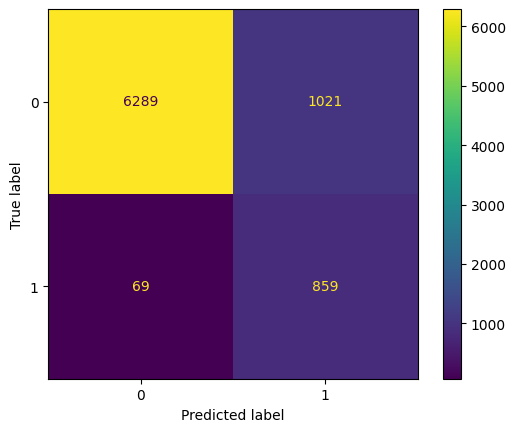

In [43]:
cm_lg_f2 = confusion_matrix(y_test, y_test_lg_f2_best)

ConfusionMatrixDisplay(confusion_matrix=cm_lg_f2).plot();

The confusion matrix shows that the True Positive label outperforms the False Negatives, showing that the lower loss of opportunity cost.

### 4.1.6. Business Metrics

In [79]:
business_perf_lg_f2 = business_metrics_func(y_test, y_test_lg_f2_best, 'lg f2')
business_perf_lg_f2

,Metric,Value
0,Model,lg f2
1,Revenue,20512
2,Cost,18419
3,ROI,0.11
4,Conversion Rate,0.46
5,Lost Opportunity,412
6,True Positive,859
7,False Positive,1021
8,True Negative,6289
9,False Negative,69


## 4.2. XGB Classifier F2

XGBoost Classifier is a decision-tree based boosting classifier with an emphasize on growing the level/depth of the tree.
Boosting classifiers in general explains the method of classifying sample of data and giving more learning weight the incorrectly classified sample and treat said sample with new model. In XGBoost classifier, this growth of learning is done for every nodes within a tree level.

### 4.2.1. Hyperparameter Tuning Preparation

While there are similar parameters being used, this part explains the parameters not used in the LightGBM classifier section :

- booster :

    This parameter determines which booster to use between `gbtree` and `gblinear`.  

- gamma :

    This parameter specifies minium loss reduction required to make a split of tree node. The larger gamma is, the more conservative the algorithm will be and would refrain to split the node.

- reg_alpha:

    L1 regularization term on weights. Increasing this value will make model more conservative. Used for high dimensionality.

- reg_lambda :
    L2 regularization term on weights. Increasing this value will make model more conservative. Used to reduce overfitting. 


In [45]:
param_xg = {
    'model__n_estimators': [400, 500, 600, 700],
    'model__learning_rate': [0.01,0.05,0.1],
    'model__booster': ['gbtree', 'gblinear'],
    'model__gamma': [0, 0.5, 1],
    'model__reg_alpha': [0, 0.5, 1],
    'model__reg_lambda': [0.5, 1, 5, 10],
    'model__base_score': [0.1, 0.2, 0.3, 0.4, 0.5]
}



In [46]:
xg_f2_cv = RandomizedSearchCV( estimator = pipe_xg, 
                                param_distributions=param_xg, 
                                n_iter=20, 
                                cv=5, 
                                # random_state=2042, 
                                scoring=f2_scorer)

### 4.1.2. Hyperparameter Tuning

In [47]:
xg_f2 = xg_f2_cv.fit(X_train, y_train)

In [48]:
best_xg_f2 = xg_f2.best_estimator_

best_xg_f2.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [49]:
y_train_xg_f2_best = best_xg_f2.predict(X_train)
y_test_xg_f2_best = best_xg_f2.predict(X_test)

### 4.1.3. F2 Scores - Overfitting Check

In [50]:
# Evaluate the performance
f2_train_xg_f2 = fbeta_score(y_train, y_train_xg_f2_best, beta=1)
f2_test_xg_f2 = fbeta_score(y_test, y_test_xg_f2_best, beta=1)

print("Evaluation Metrics")
f2_xg_eval = {
    "Metric": [ "f2 Train",      "f2 Test", "difference"],
    "Value": [  f2_train_xg_f2,  f2_test_xg_f2, abs(f2_train_xg_f2-f2_test_xg_f2)]
}

# Create DataFrame
df_f2_xg_eval = pd.DataFrame(f2_xg_eval)
df_f2_xg_eval

Evaluation Metrics


,Metric,Value
0,f2 Train,0.663970
1,f2 Test,0.617957
2,difference,0.046013


F2 scores shown that there are very small difference between the scores between the train and test set, indicating no overfitting within the model.

### 4.1.5. Confusion Matrix

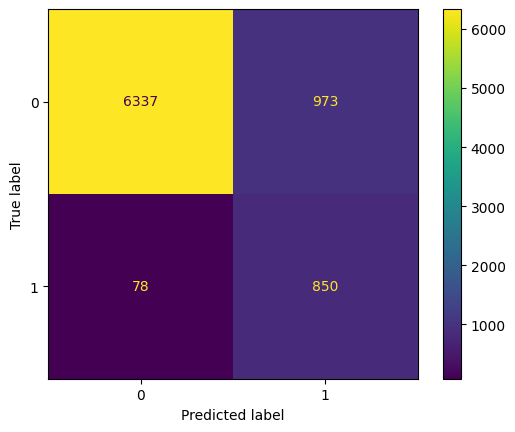

In [51]:
cm_xg_f2 = confusion_matrix(y_test, y_test_xg_f2_best)

ConfusionMatrixDisplay(confusion_matrix=cm_xg_f2).plot();

The confusion matrix shows that the True Positive label outperforms the False Negatives, showing that the lower loss of opportunity cost.

### 4.1.6. Business Metrics

In [77]:
business_perf_xg_f2 = business_metrics_func(y_test, y_test_xg_f2_best, 'XG f2')
business_perf_xg_f2

,Metric,Value
0,Model,XG f2
1,Revenue,20297
2,Cost,18116
3,ROI,0.12
4,Conversion Rate,0.47
5,Lost Opportunity,465
6,True Positive,850
7,False Positive,973
8,True Negative,6337
9,False Negative,78


# 5. Business & Model Metrics Performance Summary

In [80]:
business_summary_data = [
        ['Non Model', originaldata_costs, originaldata_income, (originaldata_income-originaldata_costs), originaldata_conv_rate, originaldata_roi],
        ['XGBoost Classifier Tuned', business_perf_xg_f2.iloc[2,1], business_perf_xg_f2.iloc[1,1], business_perf_xg_f2.iloc[1,1]-business_perf_xg_f2.iloc[2,1], business_perf_xg_f2.iloc[4,1], business_perf_xg_f2.iloc[3,1]],
        ['LigghtGBM Tuned', business_perf_lg_f2.iloc[2,1], business_perf_lg_f2.iloc[1,1], business_perf_lg_f2.iloc[1,1]-business_perf_lg_f2.iloc[2,1], business_perf_lg_f2.iloc[4,1], business_perf_lg_f2.iloc[3,1]],
        ]
business_summary = pd.DataFrame(business_summary_data, columns=['Type', 'Total Cost', 'Total Income', 'Net Profit', 'Conversion Rate', 'Net ROI'])
business_summary

,Type,Total Cost,Total Income,Net Profit,Conversion Rate,Net ROI
0,Non Model,737805,110798,-627007,0.11,-0.85
1,XGBoost Classifier Tuned,18116,20297,2181,0.47,0.12
2,LigghtGBM Tuned,18419,20512,2093,0.46,0.11


**1. Non Model Business Performance**

In this scenario the bank contacts all customers, which in test data shown conversion rate of ~11%. Here is the cost revenue calculation :

Total deposit subscription = 928 customers  
Conversion Rate = 11%
<br>Total cost = call cost on all customers + interest expense of the deposit income + deposit income tax = EUR 737,805
<br>Total income = income from deposit (all deposit values are counted as productive asset)
<br>Net ROI (Return on Investment) = -85%

**2. XGBoost Classifier Business Performance**

Following the prediction modelling using XGBoost classifier tuned to the best performance we could achieve, ROI shown to land at 12% and 47% conversion rate.

TP (Predicted Deposit, Actual Deposit) : 850
<br>FP (Predicted Deposit, Actual No Deposit) : 973
<br>FN (Predicted No Deposit, Actual Deposit) : 78
<br>TN (Predicted No Deposit, Actual No Deposit) :  6,337

Campaign will only be applicable to customers who are predicted to Deposit (TP and FP) :

Total deposit subscription = 850 of 1,825 customers   
Conversion Rate = 850/(850+973) * 100 = 46 %
<br>Total revenue =  845 x EUR 500 x income interest rate = EUR 20,297
<br>Total cost = EUR 18,116
<br>Net ROI (Return on Investment) = (20,297 - 18,116)/18,116 = 11%

**3. Comparison:**

* **Without modeling:**  
  Conversion rate   : 11%  
  Net ROI           : -85%

* **With modeling**:  
  Conversion rate   : 47%  
  Net ROI           : 11%

* **Impact of modeling:**  
  **1. Conversion Rate improved by 4.2 times**.

  **2. Return in Investment (ROI) improved by 112 fold**.

In [81]:
(0.11 - (-0.85)) / 0.85 * 100

112.94117647058823

# 6. Feature Assessments

## 6.1. Feature Importance

In [54]:
# Capturing feature importance values and feature names
column_names = best_xg_f2.named_steps['preprocessing'].get_feature_names_out()
fi_featimpo = best_xg_f2.named_steps['model'].feature_importances_

In [55]:
# Converting into dataframe
check_fi_df = pd.DataFrame({'feature': column_names, 'importance': fi_featimpo})
check_fi_df.sort_values(by='importance', ascending=False)

,feature,importance
26,nr.employed,0.452843
24,emp.var.rate,0.129853
29,duration,0.106437
20,cons.conf.idx,0.064499
22,euribor3m,0.039470
18,pdays,0.018745
23,cons.price.idx,0.018003
4,default_unknown,0.016153
11,poutcome_success,0.015632
3,contact_telephone,0.014844


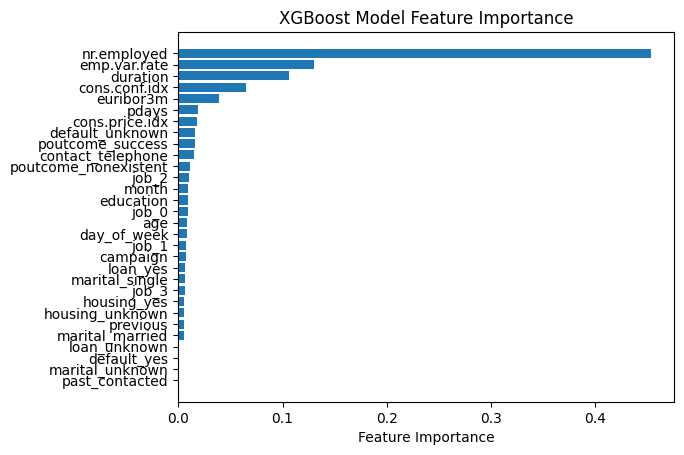

In [56]:
# Generate feature importance visualization
feature_importances = best_xg_f2.named_steps['model'].feature_importances_

feature_importances_df = pd.DataFrame({
        'Feature': column_names,
        'Importance': feature_importances
    })
sorted_fi_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.barh(sorted_fi_df['Feature'], sorted_fi_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Model Feature Importance')
plt.gca().invert_yaxis()
plt.show()

The feature importance within the model shows the features that provide different levels of influence of the target variable to predict customers' decision to do term deposit.

Notable top 5 features within this model that predicts term deposit decision are mostly macroeconomic measures that shows ***this model predicts customers' decision which relies heavily on the country's macroeconomic state***. ***Duration of the call also shown to be a strong determinant*** as it belongs in the top 3 of the list.

## 6.2. Shap

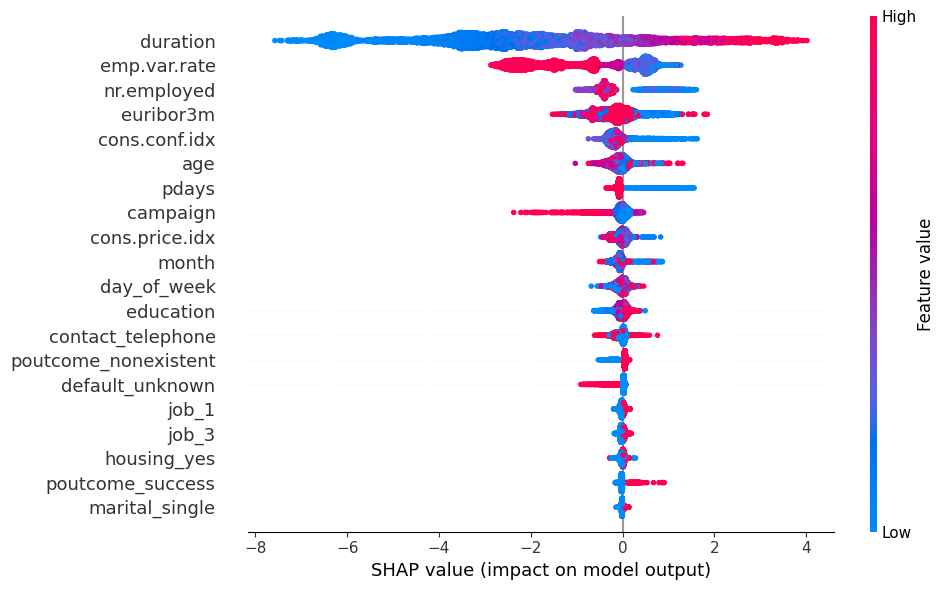

In [57]:
# Apply preprocessing to get the transformed feature names
X_train_tf = preprocessor.transform(X_train)
X_test_tf = preprocessor.transform(X_test)

# Feature name
unique_feature_names = best_xg_f2.named_steps['preprocessing'].get_feature_names_out()

# create a SHAP TreeExplainer
explainer = shap.TreeExplainer(best_xg_f2.named_steps['model'])

# calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_tf)

# visualize global feature importance
shap.summary_plot(shap_values, X_test_tf,
                  feature_names=unique_feature_names,
                  title="SHAP Summary Plot",
                  plot_size=(10, 6))

We also used SHAP (SHapley Additive exPlanations) summary plot to capture the impact of each features toward the model's output of the independent variable of customers' decision to agree to do deposit program.
  
Notable Features:

* **Duration**  
Duration shown to the strongest feature to correlate the direction of the model's predictions. Higher values, represented by red lines, shows the likelihood of a positive prediction, while lower duration value skews the model prediction toward negative output. ***Longer call duration shows higher likeliness of the client to do term deposit.***

* **emp.var.rate**  
Represents the macroeconomic measures of variations/dispersions/disparity of employment rate within the country (employment variation rate). Red lines, represented as high emp.var.rate value, positioned within the left half on the SHAP value. Which means that ***higher emp.var.rate predicts the likeliness of the client to not do the term deposit.*** 

* **nr.employed**  
Another features that represents the job market. Explained as short as "number of employees" in the dataset, we have found NR Employed could refer to the country's Natural Rate of Unemployment (NRU). NRU explains the rate of unemployment while the economy is still producing full potential output. Though not as strong of an indicator compared to the previous features, ***nr.employed affects positive likeliness of customers' decision to do term deposit when it is at its lower value.***  

* **euribor3m**  
This feature indicates interbank interest rate at which European banks are prepared to lend to one another. Higher Euribor rates generally would slow down inflation, wihle slowing down economic growth at the same time. Euribor ultimately impacts the Eurozone economy by influencing the cost of borrowing, the attractiveness of savings, and the overall level of economic activity. ***Lower euribor3m would generally skew customers' decision to do term deposit while there might be some rare instances of higher euribor3m value would yield similar result.***  

* **cons.conf.idx**  


# Export for Streamlit

In [62]:
import streamlit as st
import pandas as pd
import joblib
import pickle
import os

In [ ]:
# Save the trained pipeline to a joblib file
joblib.dump(best_xg_f2, 'pipeline_finpro_enigma.joblib')


['pipeline_finpro_enigma.joblib']

In [66]:
# Save the trained pipeline to a pickle file
with open("pipeline_enigma.pkl", "wb") as f:
    pickle.dump(best_xg_f2, f)

# 7. Conclusions and Recommendations

## 7.1. Conclusions  

We developed the best model through process of data cleaning, preprocessing, and model benchmarking to land with XGBoost Classifier. 
The model scored F2 score of ~61%, with the ability to predict true positive while surpressing the amount of false negatives to maximize customer capture. In summary, **the developed model is shown to be able help The Portugal Bank improve the marketing campaign's Conversion Rate 4.2 times and Return On Investment (ROI) 112 fold from the past marketing campaign done by the Bank.**  

## 7.2. Model Limitation

In [ ]:
display(X_train.describe(),
        X_train.describe(include='object'))

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,32881.000000,32881.000000,32881.000000,32881.000000,32881.000000,32881.000000,32881.000000,32881.000000,32881.000000,32881.000000
mean,39.942064,257.659226,2.563000,963.005748,0.172805,0.084152,93.576379,-40.513023,3.622719,5167.138265
std,10.276527,257.531174,2.771662,185.592075,0.496647,1.569707,0.578874,4.619861,1.733910,72.224863
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,83.000000,4199.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
count,32881,32881,32881,32881,32881,32881,32881,32881,32881,32881
unique,12,4,8,3,3,3,2,10,5,3
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent
freq,8269,19891,9718,26038,17241,27110,20884,11014,6834,28397


**Model Limitation**

1. This model is limited to historical data that is available.  
2. The model predicts of customers' term deposit subscription within these conidtions of data and features within the observed data:
    - Customer age between 18-83 years old.
    - Marketing call contact duration up to 4199 seconds.
    - Number of contact performed during the campaign campaign up to 56 times.
    - Number of contact performed before this campaign up to 7 times.
    - And limitation of various economic indicators of the time the campaign ran.
3. Prediction may vary with new observations outside of the previously available data.
4. Changes in models used, features used, to treat the similar data would yield a different result in predicting customer's decision.

## 7.3. Recommendations

### 7.3.1. Business Insights

Based on our data analysis, **we recommend telemarketing efforts towards clients who are shown to have higher conversion rates.**

Additionally, our machine learning model have shown that demographic characteristics do not significantly impact to subscribe decision. Instead, numbers of macroeconimic indicators and call durations would bring more impact in the likeliness of subscribing to a term deposit service.

### 7.3.2. Recommendation for Marketing Team (WIP, needs more work) 

  1. **Alternative Model**   
      Since our model is limited to historical data, we took the initiative to create an alternative model where this model can be used to predict new fresh customers who have never been contacted at all. **This model** also provides good performance with a Recall score of 0.84 (focusing on True actual comes) and **increases CVR by 6.61 times and reduces telemarketing costs by 7.82 times**.  

  2. **Targeted Campaign**  
      - Use the predictive model to identify **customers who are most likely to subscribe** to a term deposit and design targeted marketing campaigns to engage these potential customers.  
      - In section 7.2 (Global Explanation: Shap), we found that the longer the duration of the call, the more likely it is that the client will agree to the deposit. We also found spesific month and contact type have significant impact. This global explanation was also supported by the findings in predictive modelling in section 7.3 (Local explanation: Counterfactual) where the desired outcomes are highly influenced by those features. 

  3. **Spesific Recommendation Samples**  
      Based on section 7.3 (Local explanation: Counterfactual), we found some examples how we can change the non-deposit customers to subscribe the deposit.  
      - 30-year old single customers who worked as an admin with housing loan via cellular for 40 mins in May  
      - 36-year old married customers who worked in services with no loan and credit via cellular for around 31 minutes.  
      - 54-year old married customers who worked in management with personal loan via celullar in July for around 1 hour.    
      - 31-year old divorced customers who worked as a technician via cellular in Dec for 12 minutes or in March for around 56 minutes.  
      - 36-year old married customers who worked as blue-collar via cellular on Friday, July for more than 1 hour.

  4. **Customer Database**  
      To ensure the accuracy and relevance of predictive models, it's crucial to maintain a robust customer database and collect high-quality data. This involves several key practices based on our EDA findings:  
      - **Maintain Data Integrity**: Establish a reliable system to store and manage customer data. Regularly update the database to prevent data from becoming outdated, and continuously monitor for data drift—a situation where changes in data patterns over time can reduce the accuracy of our model.  
      - **Ensure Complete and Accurate Data Collection**: Encourage customers to provide complete information, avoiding placeholders like 'Unknown.' Collect comprehensive economic details, such as income, which are vital for accurate analysis and modeling.   
      - **Capture Important Behavioral Data**: Include additional relevant data points, such as call timestamps, to understand customer behavior over time. This temporal information can improve the model’s predictive power by highlighting trends and patterns.  

  5. **Campaign Regulation**  
      Define a guidelines based on the model's insights to improve the probability of customers subscriptions. Use these regulations to refine campaign strategies and improve conversion rates. The recommendations are **what's the maximum call should we perform for a customer(in this case 56 max calls - based on our EDA findings), how many days should we call for a month, etc**.

### 7.3.3. Model Improvement Recommendations

1. Since our model relies heavily on macroeconomic measures, further improvement toward the model is to find a way to either (a) find possibillity to simplify the macroeconomic features, and (b) emphasize more on customer characteristic features. This is to ensure we can capture better pattern of customer characteristics to predict the behaviors on term deposit subscription.     
2. There needs to be a better set of components involved iwthin the calculation of the costs and incomes as this was highly assumed through various sources of reference and reports to calculate the income and costs, while there are probability of invalidity within the calculation method.